# PlatVillage Dataset: Proyecto de análisis de datos y creación de MLP

*Librerías*

In [11]:
# Importación de librerías y config entorno
import os
from pathlib import Path
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


*Configuración segura de credenciales Kaggle para acceder a los datos*

*Importante!: Para que el Dataset sea descargado y utilizado en este Colab se requiere la creación de un Secret propio para continuar con la ejecución.*

Paso a paso:
1. Seleccionar icono de llave en la zona izquierda del menú de Colab.
2. Colocar en casilla de nombre 'KAGGLE_KEY'.
3. Agregar Token entregado por la página Kaggle para el dataset PlantVillage

  3.1 https://www.kaggle.com/

  3.2 Iniciar sesión.

  3.3 Ir a perfil de usuario

  3.4 Seleccionar 'Settings' y presionar botón 'API Tokens' para generar un nuevo token ('Generate New Token).

  3.5 Copiar zona de 'API TOKEN' y pegar en sección de 'valor' a la derecha del nombre asignado.
  
  3.6 Activar 'Acceso desde notebook'

In [12]:
import os
from google.colab import userdata

try:
    # Intenta leer el token desde los secretos seguros de Colab
    kaggle_token = userdata.get('KAGGLE_KEY')

    # Configura el directorio y escribe el token de forma segura
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    token_path = os.path.expanduser('~/.kaggle/access_token')

    with open(token_path, 'w') as f:
        f.write(kaggle_token)

    os.chmod(token_path, 0o600)
    print("Credenciales de Kaggle configuradas de forma segura")

except Exception as e:
    print("No se encontró el secreto 'KAGGLE_KEY'.")

Credenciales de Kaggle configuradas de forma segura


*Ruta de descarga*

In [13]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q -o plantdisease.zip -d dataset
print("Dataset descargado y descomprimido correctamente")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
plantdisease.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset descargado y descomprimido correctamente


In [14]:
ruta_dataset = "/content/dataset/PlantVillage"

*Visualización de clases antes del preprocesamiento*

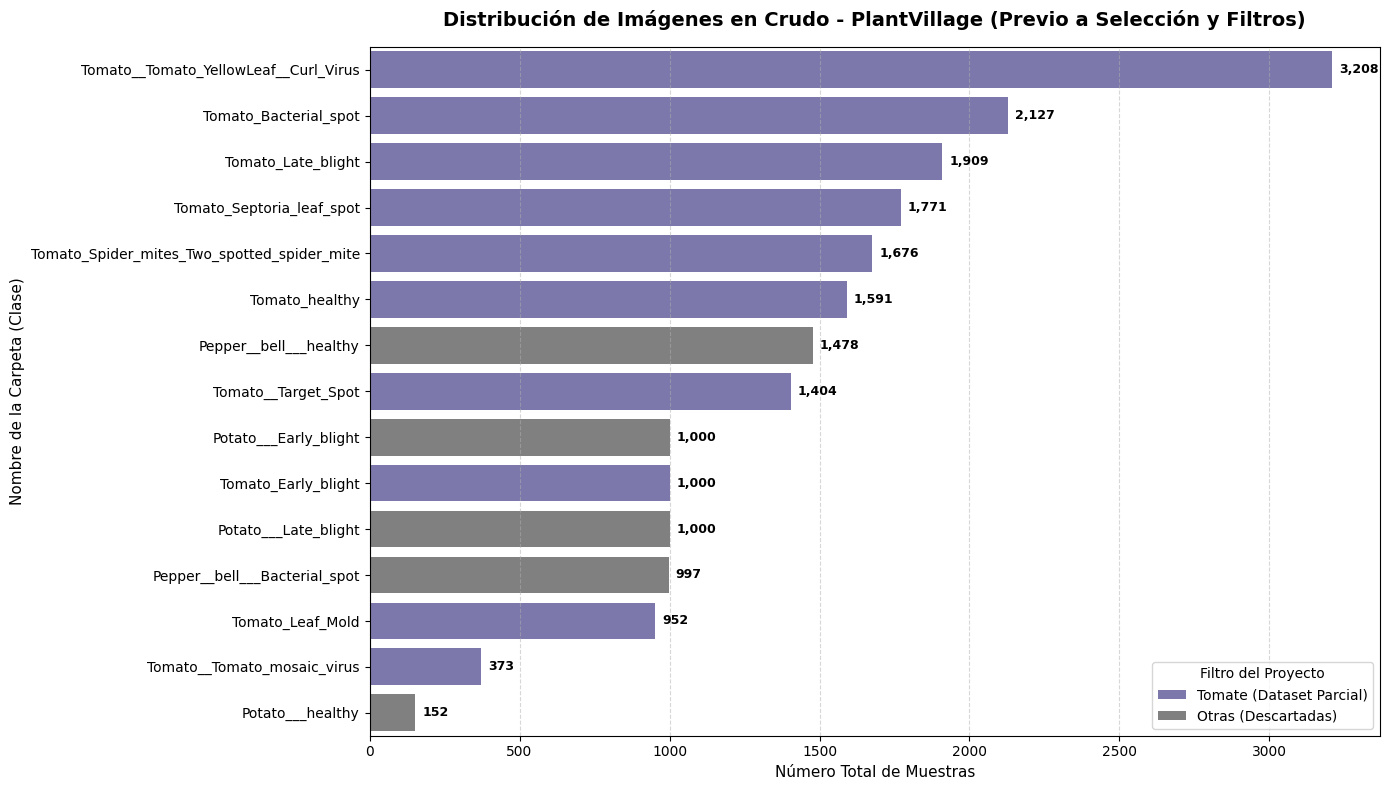

In [15]:
# Gráfico de datos crudos

dataset_raw_path = "/content/dataset/PlantVillage"
valid_exts = {'.jpg', '.jpeg', '.png'}

# Conteo optimizado usando os.scandir
data_counts = []
with os.scandir(dataset_raw_path) as it:
    for entry in it:
        if entry.is_dir():
            # Itera de forma eficiente sin cargar listas masivas
            count = sum(1 for f in os.scandir(entry.path) if f.is_file() and os.path.splitext(f.name)[1].lower() in valid_exts)
            data_counts.append({'Clase': entry.name, 'Cantidad': count})

df_raw = pd.DataFrame(data_counts).sort_values(by='Cantidad', ascending=False).reset_index(drop=True)
df_raw['Variante'] = df_raw['Clase'].apply(lambda x: 'Tomate (Dataset Parcial)' if x.startswith('Tomato') else 'Otras (Descartadas)')

# Gráfico
plt.figure(figsize=(14, 8))
palette = {'Tomate (Dataset Parcial)': '#7570b3', 'Otras (Descartadas)': '#808080'}

ax = sns.barplot(
    data=df_raw,
    x='Cantidad',
    y='Clase',
    hue='Variante',
    dodge=False,
    palette=palette
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width):,}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=9, color='black', weight='bold')

plt.title("Distribución de Imágenes en Crudo - PlantVillage (Previo a Selección y Filtros)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Número Total de Muestras", fontsize=11)
plt.ylabel("Nombre de la Carpeta (Clase)", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Filtro del Proyecto', loc='lower right')
plt.tight_layout()
plt.show()

In [16]:
# Análisis de resultados
  # Se descartan 5 categorías relacionadas a Peper y Potato (4.627 imágenes). Dado que el proyecto se enfoca
  # en las imágenes distribuidas entre 10 patologías de los tomates

  # Existe descabalce de clases crítico entre Tomato__Tomato_TellowLeaf__Curl_Virus y Tomato_Tomato_mosaic_virus

  # Dado que hay diferencias críticas entre los subconjuntos de tomate, se justifica que el modelo no sea capaz de ser entrenado
  # a menos que se incorpore class_weoght y/o Data augmentation. De lo contrario, el modelo se verá obligado a ignorar los patrones
  # del virus mosaico para maximizar accuracy a costa de las clases minoritarias.

*Definición de parámetros*

In [20]:
# Parámetros y reproducibilidad
SEED = 42
tf.keras.utils.set_random_seed(SEED)  # Fija semilla en TensorFlow, Python y NumPy

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
DATASET_PATH = Path("/content/dataset/PlantVillage")

# Filtrado automático de variable tomate
# Detecta y ordena automáticamente solo las subcarpetas del monocultivo objetivo
CLASES_TOMATE = sorted([
    d.name for d in DATASET_PATH.iterdir()
    if d.is_dir() and d.name.startswith("Tomato")
])

print(f"Total de clases detectadas en la variante: {len(CLASES_TOMATE)}")
for i, clase in enumerate(CLASES_TOMATE, 1):
    print(f"  {i:02d}. {clase}")

Total de clases detectadas en la variante: 10
  01. Tomato_Bacterial_spot
  02. Tomato_Early_blight
  03. Tomato_Late_blight
  04. Tomato_Leaf_Mold
  05. Tomato_Septoria_leaf_spot
  06. Tomato_Spider_mites_Two_spotted_spider_mite
  07. Tomato__Target_Spot
  08. Tomato__Tomato_YellowLeaf__Curl_Virus
  09. Tomato__Tomato_mosaic_virus
  10. Tomato_healthy


*Verificación de integridad de las imágenes y limpieza*

In [18]:
# Verificación de integridad y limpieza

# Usamos la ruta y la lista de clases definidas en el bloque anterior
dataset_dir = DATASET_PATH
clases_objetivo = CLASES_TOMATE

archivos_revisados = 0
archivos_corruptos = 0
archivos_vacios = 0

print(" Iniciando auditoría e integridad física de las imágenes en crudo...")

for clase in clases_objetivo:
    ruta_clase = dataset_dir / clase
    if not ruta_clase.exists():
        continue

    for archivo in ruta_clase.glob("*"):
        if archivo.is_file():
            archivos_revisados += 1

            # Comprobar si el archivo pesa 0 bytes
            if archivo.stat().st_size == 0:
                print(f" Archivo vacío (0 bytes) detectado y eliminado: {archivo.name}")
                archivo.unlink()
                archivos_vacios += 1
                continue

            # Comprobar integridad con Pillow (PIL.Image.verify())
            try:
                with Image.open(archivo) as img:
                    img.verify() # Verifica la estructura interna del archivo de imagen
            except (IOError, SyntaxError, Exception) as e:
                print(f"Imagen corrupta/dañada detectada y eliminada ({archivo.name}): {e}")
                try:
                    archivo.unlink() # Borra el archivo defectuoso para evitar fallos en tf.data
                except Exception:
                    pass
                archivos_corruptos += 1

print(" Reporte de auditoría de integridad de los datos (EDA)")
print(f"• Total de archivos escaneados : {archivos_revisados:,}")
print(f"• Archivos vacíos (0 bytes)    : {archivos_vacios}")
print(f"• Archivos corruptos descartados: {archivos_corruptos}")
print(f"• Archivos sanos y listos       : {archivos_revisados - (archivos_vacios + archivos_corruptos):,}")

 Iniciando auditoría e integridad física de las imágenes en crudo...
 Archivo vacío (0 bytes) detectado y eliminado: svn-r6Yb5c
 Reporte de auditoría de integridad de los datos (EDA)
• Total de archivos escaneados : 16,012
• Archivos vacíos (0 bytes)    : 1
• Archivos corruptos descartados: 0
• Archivos sanos y listos       : 16,011


*Partición de datos: Entrenamiento, Validación y Pruebas*

In [21]:
# Cargar entrenamiento (70% del total, dejando un 30% reservado para validación/test)
datos_entrenamiento = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASES_TOMATE
)

# Cargar el bloque temporal (el otro 30% restante)
datos_validacion_temporal = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASES_TOMATE
)

nombres_clases = datos_entrenamiento.class_names

# Dividir ese 30% en dos mitades iguales: 15% para validación real y 15% para test
lotes_totales = tf.data.experimental.cardinality(datos_validacion_temporal)
datos_test = datos_validacion_temporal.take(lotes_totales // 2)
datos_validacion = datos_validacion_temporal.skip(lotes_totales // 2)

print(f"Dataset cargado correctamente. Clases: {len(nombres_clases)}")

Found 16011 files belonging to 10 classes.
Using 11208 files for training.
Found 16011 files belonging to 10 classes.
Using 4803 files for validation.
Dataset cargado correctamente. Clases: 10


*Inspección de resolución de imágenes* -
*Variabilidad entre clases* -
*Análisis cualitativo*

Analizando dimensiones originales (resolución nativa) en disco...
Resolución nativa promedio detectada: 256 x 256 píxeles.
Justificación del Pipeline: Se realiza un redimensionamiento (resize) a 128x128 para estandarizar las entradas, acelerar el entrenamiento en GPU y mitigar el costo paramétrico del MLP, asumiendo un riesgo controlado de pérdida de micro-detalles en lesiones necróticas muy finas.

Generando grid comparativo (Hojas Sanas vs. Enfermas)


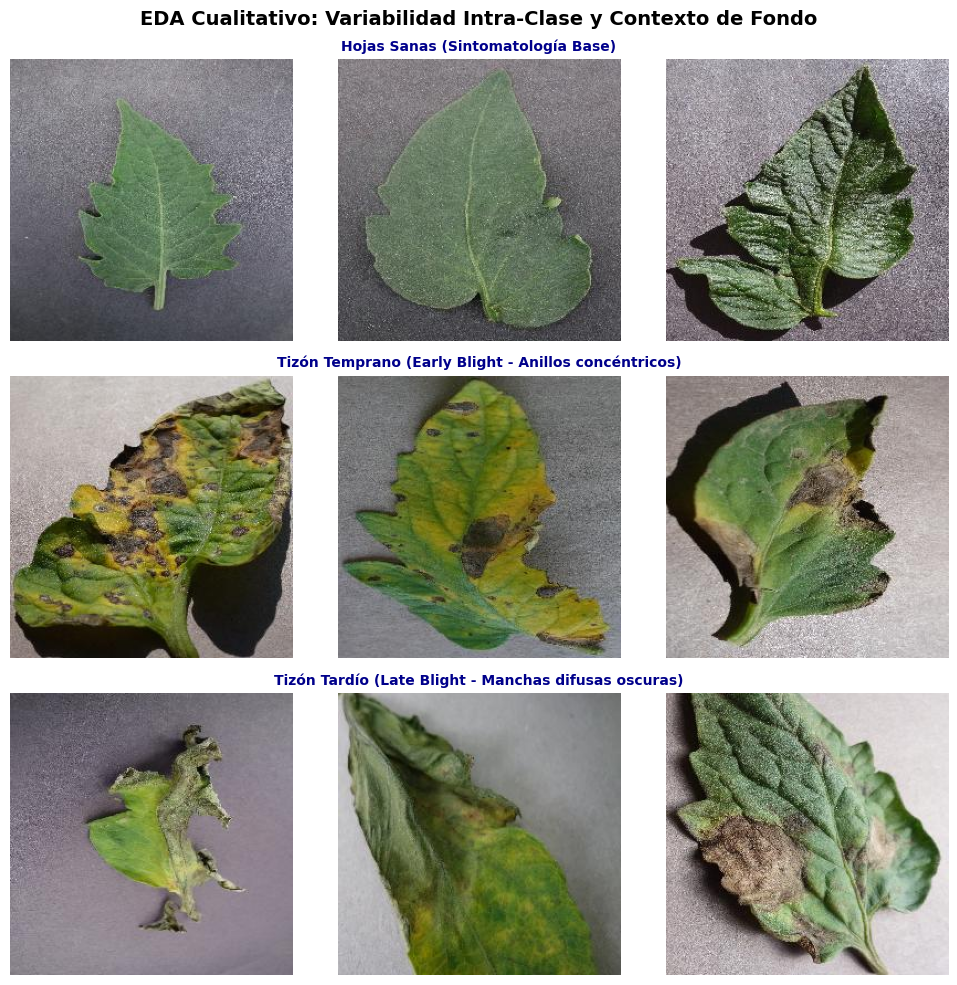

In [22]:
# Inspección de resolución nativa - Grid variabilidad intra-classes - Análisis cualitativo (entorno)
# 1. ANÁLISIS DE RESOLUCIÓN NATIVA
print("Analizando dimensiones originales (resolución nativa) en disco...")
anchos, altos = [], []

# Muestreamos algunas imágenes de distintas clases para medir su resolución real
for clase in nombres_clases[:3]: # Revisamos las primeras clases
    ruta_clase = DATASET_PATH / clase
    imagenes_muestra = list(ruta_clase.glob("*"))[:10] # Tomamos 10 de ejemplo por clase
    for img_path in imagenes_muestra:
        with Image.open(img_path) as img:
            w, h = img.size
            anchos.append(w)
            altos.append(h)

ancho_promedio = np.mean(anchos)
alto_promedio = np.mean(altos)
print(f"Resolución nativa promedio detectada: {int(ancho_promedio)} x {int(alto_promedio)} píxeles.")
print(f"Justificación del Pipeline: Se realiza un redimensionamiento (resize) a {IMG_SIZE[0]}x{IMG_SIZE[1]} para estandarizar las entradas, acelerar el entrenamiento en GPU y mitigar el costo paramétrico del MLP, asumiendo un riesgo controlado de pérdida de micro-detalles en lesiones necróticas muy finas.\n")

# 2. GRID DE VARIABILIDAD VISUAL INTRA-CLASE Y ANÁLISIS DE FONDOS
print("Generando grid comparativo (Hojas Sanas vs. Enfermas)")

# Buscamos una clase sana y un par de clases enfermas (ej. Early blight vs Late blight)
clase_sana = "Tomato_healthy"
clase_enferma_1 = "Tomato_Early_blight"
clase_enferma_2 = "Tomato_Late_blight"

def obtener_imagenes_aleatorias(nombre_clase, n=3):
    ruta = DATASET_PATH / nombre_clase
    archivos = list(ruta.glob("*"))
    muestras = random.sample(archivos, min(n, len(archivos)))
    return [Image.open(p) for p in muestras]

imgs_sanas = obtener_imagenes_aleatorias(clase_sana, 3)
imgs_early = obtener_imagenes_aleatorias(clase_enferma_1, 3)
imgs_late = obtener_imagenes_aleatorias(clase_enferma_2, 3)

# Creamos la figura comparativa para el informe
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
categorias = [("Hojas Sanas (Sintomatología Base)", imgs_sanas),
              ("Tizón Temprano (Early Blight - Anillos concéntricos)", imgs_early),
              ("Tizón Tardío (Late Blight - Manchas difusas oscuras)", imgs_late)]

for row_idx, (titulo_categoria, lista_imgs) in enumerate(categorias):
    for col_idx, img in enumerate(lista_imgs):
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis("off")
        if col_idx == 1:
            ax.set_title(titulo_categoria, fontsize=10, weight='bold', color='darkblue')

plt.suptitle("EDA Cualitativo: Variabilidad Intra-Clase y Contexto de Fondo", fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

*Balance de clases*

In [23]:
# Balance de clases
# Extraer las etiquetas reales de todo el conjunto de entrenamiento de TensorFlow
ds_train = datos_entrenamiento
ds_val = datos_validacion
ds_test = datos_test

y_train_indices = []
for _, etiquetas_batch in ds_train:
    # Como label_mode="categorical", las etiquetas son one-hot.
    # Usamos np.argmax para recuperar el índice de la clase (0 al 9).
    indices = np.argmax(etiquetas_batch.numpy(), axis=1)
    y_train_indices.extend(indices)

y_train_indices = np.array(y_train_indices)

# Identificar las clases únicas presentes
clases_unicas = np.unique(y_train_indices)

# Calcular los pesos balanceados inversamente proporcionales a la frecuencia
pesos_calculados = compute_class_weight(
    class_weight="balanced",
    classes=clases_unicas,
    y=y_train_indices
)

# Construir el diccionario que exige Keras: {indice_clase: peso_numérico}
class_weights_dict = dict(zip(clases_unicas, pesos_calculados))

print("Ponderación balanceada por clase (Class Weights):")
for idx, peso in class_weights_dict.items():
    print(f"  • {nombres_clases[idx]}: {peso:.2f}")

Ponderación balanceada por clase (Class Weights):
  • Tomato_Bacterial_spot: 0.74
  • Tomato_Early_blight: 1.56
  • Tomato_Late_blight: 0.83
  • Tomato_Leaf_Mold: 1.67
  • Tomato_Septoria_leaf_spot: 0.92
  • Tomato_Spider_mites_Two_spotted_spider_mite: 0.94
  • Tomato__Target_Spot: 1.16
  • Tomato__Tomato_YellowLeaf__Curl_Virus: 0.51
  • Tomato__Tomato_mosaic_virus: 4.21
  • Tomato_healthy: 1.02


*Diseño de modelo MLP (incluye técnicas de regularización)*

In [24]:
# Diseño y compilación del modelo (regularización y dropout)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Rescaling, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Definir el modelo secuencial
modelo = Sequential([
    Input(shape=(128, 128, 3)),
    Rescaling(1./255),
    Flatten(),

    # Capa Oculta 1 con Normalización y Dropout para mitigar sobreajuste
    Dense(256, use_bias=False),
    BatchNormalization(),
    keras.layers.Activation('relu'),
    Dropout(0.4),

    # Capa Oculta 2
    Dense(128, use_bias=False),
    BatchNormalization(),
    keras.layers.Activation('relu'),
    Dropout(0.3),

    # Capa de Salida Multiclase (10 clases de tomate con Softmax)
    Dense(10, activation='softmax') # Función de activación, entrega vector de puntuaciones. En otras palabras , divide el valor exponencial de cada clase entre la suma de los exponenciales de todas las clases disponibles
], name="MLP_Regularizado")

# Compilación del modelo
modelo.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumen de la arquitectura y cantidad de parámetros
modelo.summary()

Model: "MLP_Regularizado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,582,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,618,506 (48.14 MB)

 Trainable params: 12,617,738 (48.13 MB)

 Non-trainable params: 768 (3.00 KB)

In [25]:
# Interpretación de resultados
  # rescaling: Recibe total de imágenes, representa el tamaño del lote dinámico
  # flatten: Estira la matriz de la imagen hasta transformarlo en un vector unidimensional (destrucción de estructura espacial)
  # dense: Indica que cada entrada es conectada con 256 neuronas
  # batch_normalization (Estandarización de activaciones de las capas ocultas Media / desv. estándar) y dropout:
    # Aprende 4 parámetros para cada neurona, a modo de estandarizar las activaciones.
    # dropout apaga conexiones aleatoriamente (aporta 0 parámetros estructurales)
  # dense_1: (capa 2) reduce la representación de neuronas de 256 a 128. Dado que hay menos entradas, la cantidad de pesos es menor.
  # dense_2: (capa salida) las anteriores 128 neuronas son conectadas con 10 neuronas (de salida) una por cada una de las patologías.
    # Se aplica la función de activación Softmax

*Callbacks y entrenamiento con ponderaciones*

In [26]:
# Callback = monitoreo / modificación del comportamiento del modelo

# EarlyStopping: Detiene el entrenamiento si la pérdida de validación deja de mejorar
# restore_best_weights=True garantiza que se mantengan los mejores pesos obtenidos
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Reduce la tasa de aprendizaje si el modelo se estanca (plateau)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_entrenamiento = [early_stopping, reduce_lr]

# Entrenamiento integrando el balanceo de clases
print("Iniciando el entrenamiento del modelo ")
history = modelo.fit(
    datos_entrenamiento,
    validation_data=datos_validacion,
    epochs=25, # Un límite superior seguro, ya que EarlyStopping controlará el fin
    class_weight=class_weights_dict, # Ponderación para clases minoritarias
    callbacks=callbacks_entrenamiento
)

Iniciando el entrenamiento del modelo 
Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 108s 301ms/step - accuracy: 0.4906 - loss: 1.5234 - val_accuracy: 0.3683 - val_loss: 1.7876 - learning_rate: 0.0010
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 132s 273ms/step - accuracy: 0.6489 - loss: 1.0417 - val_accuracy: 0.4723 - val_loss: 1.4578 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 273ms/step - accuracy: 0.7018 - loss: 0.8723 - val_accuracy: 0.3866 - val_loss: 1.8919 - learning_rate: 0.0010
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.7274 - loss: 0.7774 - val_accuracy: 0.5701 - val_loss: 1.1368 - learning_rate: 0.0010
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.7637 - loss: 0.6859 - val_accuracy: 0.4332 - val_loss: 2.5463 - learning_rate: 0.0010
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7769 - loss: 0.6594
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
351/351 ━━━━━━━━━━

*Evaluación de desempeño: Curvas de aprendizaje, matriz de confusión y gráfico de dispersión*

Reporte de Clasificación en Conjunto de Test Independiente:

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.87      0.92      0.90       298
                        Tomato_Early_blight       0.61      0.61      0.61       134
                         Tomato_Late_blight       0.83      0.79      0.81       265
                           Tomato_Leaf_Mold       0.79      0.83      0.81       132
                  Tomato_Septoria_leaf_spot       0.89      0.81      0.85       274
Tomato_Spider_mites_Two_spotted_spider_mite       0.80      0.82      0.81       240
                        Tomato__Target_Spot       0.77      0.81      0.79       237
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.96      0.91      0.93       491
                Tomato__Tomato_mosaic_virus       0.70      0.91      0.79        55
                             Tomato_healthy       0.94      0.95      0.94       274

  

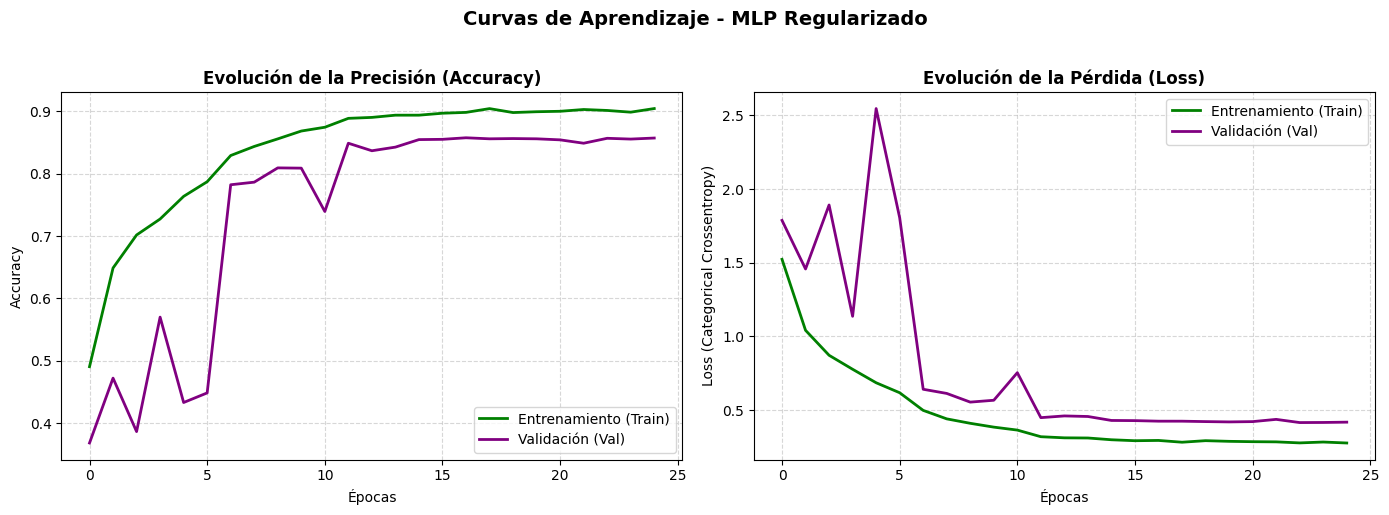

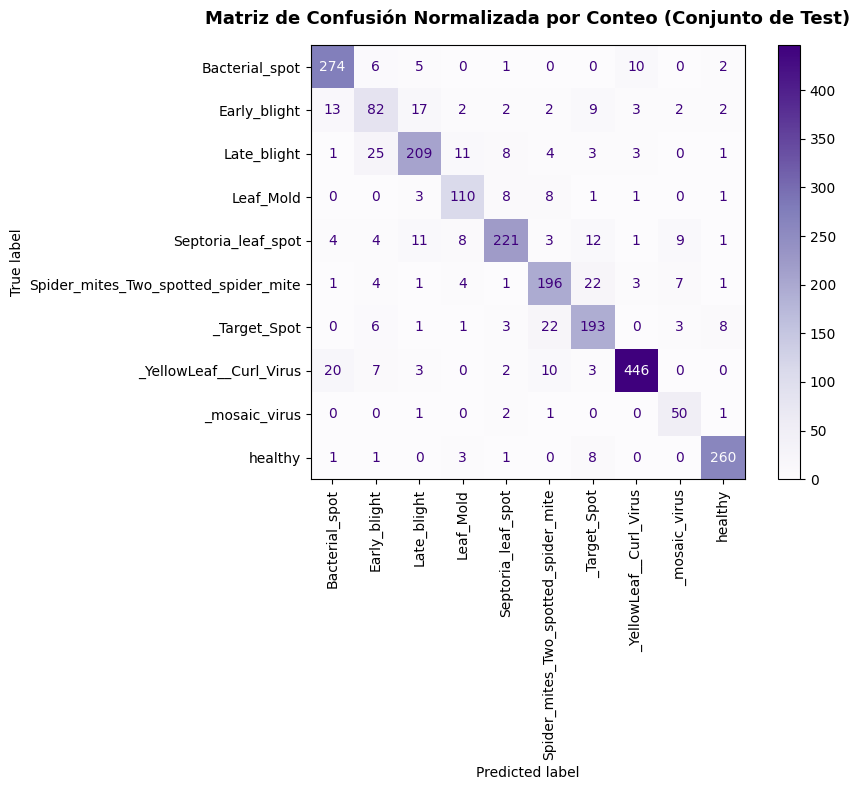

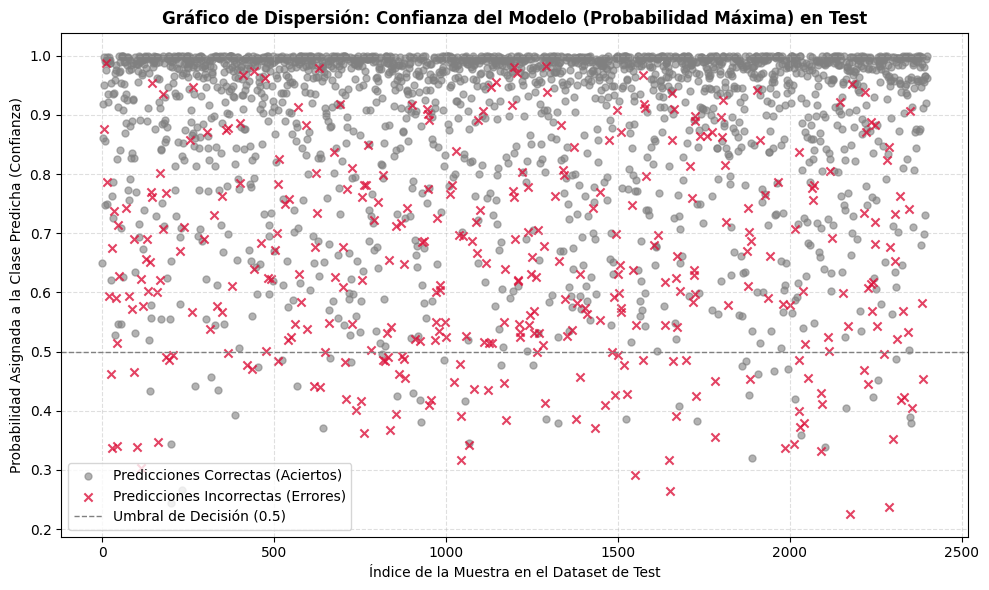

In [27]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Extracción de etiquetas reales y predicciones sobre el conjunto de TEST independiente
y_true_test = []
y_pred_test = []
y_prob_test = []

for imagenes, etiquetas in datos_test:
    predicciones = modelo.predict(imagenes, verbose=0)
    y_pred_test.extend(np.argmax(predicciones, axis=1))
    y_true_test.extend(np.argmax(etiquetas.numpy(), axis=1))
    # Guardamos la probabilidad máxima predicha para medir la "confianza" del modelo
    y_prob_test.extend(np.max(predicciones, axis=1))

y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)
y_prob_test = np.array(y_prob_test)

# Reporte de Clasificación detallado en Test
print("Reporte de Clasificación en Conjunto de Test Independiente:\n")
print(classification_report(y_true_test, y_pred_test, target_names=nombres_clases))

# Curvas de aprendizaje (Accuracy y Loss: Entrenamiento vs Validación)
plt.figure(figsize=(14, 5))

# Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento (Train)', color='green',linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación (Val)', color='purple', linewidth=2)
plt.title('Evolución de la Precisión (Accuracy)', fontsize=12, weight='bold')
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento (Train)', color='green', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación (Val)', color='purple', linewidth=2)
plt.title('Evolución de la Pérdida (Loss)', fontsize=12, weight='bold')
plt.xlabel('Épocas', fontsize=10)
plt.ylabel('Loss (Categorical Crossentropy)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Curvas de Aprendizaje - MLP Regularizado", fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Matriz de confusión en conjunto test
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[c.replace('Tomato_', '') for c in nombres_clases])
disp.plot(cmap=plt.cm.Purples, xticks_rotation='vertical', ax=plt.gca(), values_format='d')
plt.title("Matriz de Confusión Normalizada por Conteo (Conjunto de Test)", fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# Gráfico de dispersión (Confianza de la Predicción vs Acierto / Error)

plt.figure(figsize=(10, 6))
aciertos = (y_true_test == y_pred_test)

# Creamos un scatter plot: Eje X = Índice de muestra en test, Eje Y = Probabilidad predicha (Confianza)
plt.scatter(np.where(aciertos)[0], y_prob_test[aciertos], color='grey', alpha=0.6, label='Predicciones Correctas (Aciertos)', s=25)
plt.scatter(np.where(~aciertos)[0], y_prob_test[~aciertos], color='crimson', alpha=0.8, label='Predicciones Incorrectas (Errores)', s=35, marker='x')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Umbral de Decisión (0.5)')
plt.title("Gráfico de Dispersión: Confianza del Modelo (Probabilidad Máxima) en Test", fontsize=12, weight='bold')
plt.xlabel("Índice de la Muestra en el Dataset de Test", fontsize=10)
plt.ylabel("Probabilidad Asignada a la Clase Predicha (Confianza)", fontsize=10)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



# Reporte técnico y conclusiones
*Clasificación de enfermedades en hojas de tomate*

Ejercicio de perceptrón multicapa con regularización.

#Problema:
Las enfermedades presentes en los cultivos influyen directamente en la pérdida de las producciones agrícolas. El presente proyecto consiste en implementar un sistema automatizado de aprendizaje supervisado capaz de diagnosticar y clasificar 10 categorías distintas de patologías presentes en los tomates a partir del subconjunto de datos optimizado de PlantVillage.

# Metodología aplicada
Metodología estándar CRISP-DM
* Comprensión del negocio y los datos disponibles: Análisis de distribución de los datos
* Preparación de los datos: Análisis de integridad de los datos. Partición del dataset
* Modelamiento: Construcción de perceptrón multicapa. Incluye capas de regularización estructural y compensación de desbalance muestral (class_weight)
* Evaluación: Análisis con reportes de clasificación (matriz de confusión) y auditoría de errores.

# Arquitectura y manejo de datos
* Partición en train, val y test para garantizar la capacidad de generalización del modelo con datos nunca antes vistos.
* Mitigación de desbalance muestral: Se intrgró una ponderación inversa a la frecuencia de las clases (a nivel de función de pérdida -> categorical_crossentropy), evitando que el optimizador no tome en cuenta a las categorías con menor representación
* Regularización contra el sobreajuste:
  * Dropout integrado en capas y Batch normalización (para acelerar el entrenamiento y mejorar la estabilidad al normalizar las activaciones de una capa para obtener media = 0 y varianza = 1) posterior a aplastar los atributos de entreda. De este modo, la memorización del ruido presente en los datos es anulada.
  * Configucación de EarlyStopping monitorizando val_loss con patience = 5 y restaruración automática de pesos. Previene la degradación por sobreentrenamiento.

# Análisis de resultados
 * El modelo logra superar limitaciones iniciales estabilizando su convergencia (es decir, el punto de entrenamiento en donde el modelo aprende suficiente y su tasa de error deja de disminuir (estabilización de pesos y sesgos)) con ReduceLROnPlateau
 * Matriz de confusión y reporte por clase: Efectividad en clases con patrones macroscópicos con alto contraste. El modelo es limitado al carecer de la capacidad de aislar contornos espaciales locales (confusión entre tomato_early_blight y tomato_late_blight)

 # Limitaciones técnicas del modelo
 * Destrucción de estructura espacial a causa de Flatten
 * Ausencia de invarianza a traslación. Dependiendo del lugar de las lesiones de la hoja de la planta, se aplican pesos completamente distintos. Esto obliga a mantener parámetros redundantes
 * Costo paramétrico ineficiente: Propenso a sobreajuste por la densidad en las conexiones entre capas

 # Conclusiones
 El desarrollo del proyecto demuestra un flujo de preprocesamiento, balanceo y control de sobreajuste.

 *Propuestas* : Para superar las limitaciones de MLP, se propone una transición a redes neuronales convolucionales junto con la implementación de Transfer learning. De este modo, será posible usar modelos pre-entrenados (MobileNetVT2 y /o ResNet) Lo cual, permitirá mantener extractores de caracteísticas especiales para potenciar el desempeño predictivo y disminuir el costo computacional.